# Getting started
## Introduction

This page gives a short overview over the basic usage and functionality of magmeas. For this, we are going to use VSM-data from a publically available [example dataset uploaded to Nomad](https://nomad-lab.eu/prod/v1/gui/user/uploads/upload/id/dyT-vLgKTkqK5JeSy_HWwA/files/IFW_VSM_RawData).

When you are using your own measurement files, make sure that the .DAT files contain the necessary sample information. Refer to the [magmeas README](https://github.com/MaMMoS-project/magmeas) for more information. Alternatively the input of sample information is also possible manually (more information [here](https://mammos-project.github.io/magmeas/magmeas.html#magmeas.base.VSM.reload_qd)).

## Data analysis


In [2]:
import magmeas

dataDir = "IFW_VSM_RawData/"

Let's start with an M(H) hysteresis loop. The magmeas package can automatically read the example dataset and calculates some extrinsic properties.

In [3]:
mh = magmeas.MH_major(dataDir + "VSM_MH.DAT")

print(mh.remanence)
print(mh.coercivity)

Remanence(value=0.39461314771557665, unit=MA / m)
CoercivityHc(value=0.2453529830215174, unit=MA / m)


Since the extrinsic properties are stored as mammos_entity. Entity objects, we can also get information about their ontology.

In [4]:
mh.BHmax.ontology.get_annotations()

{'wikipediaReference': [locstr('https://en.wikipedia.org/wiki/Maximum_energy_product', '')],
 'altLabel': [locstr('(BH)max', '')],
 'prefLabel': [locstr('MaximumEnergyProduct', 'en')],
 'elucidation': [locstr('The value of the maximum energy product (BH)max is deduced from a\nplot of BH(B) for all points of the second quadrant of the B-H\nhysteresis loop. BH varies with B going through a maximum value (BH)max\nfor a particular value of B.\n\n(BH)max equals the area of the largest second-quadrant rectangle which\nfits under the B-H loop.\n\nThe maximum energy product is considered to be the best single index\nof quality of a permanent magnet material.\nIt is twice the energy stored in the stray field of the magnet of\noptimal shape.', 'en')]}

## Plotting

There is also plotting functionality compatible with common matplolib keyword arguments and the ability to either pass existing matplotlib objects to the method or returning dynamically generated figures and axes for additional formatting, enabling the integration of magmeas features in common plotting workflows. In the example below we're doing the latter option.

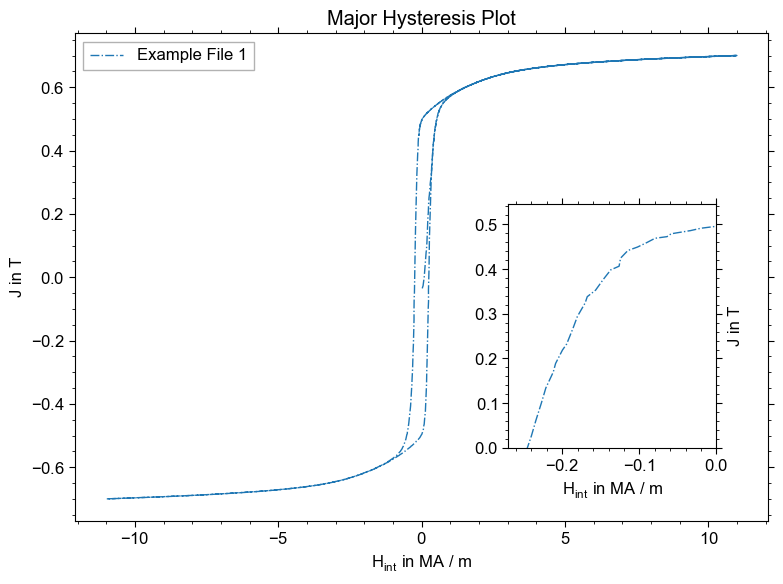

In [5]:
fig, ax1, ax2 = mh.plot(unit=("MA/m", "T"), linestyle="-.", label="Example File 1")
ax1.set_title("Major Hysteresis Plot")
ax1.legend()

In case the plotting functionality of magmeas is not sufficient we can also access the measurement values such as magnetic field H, magnetization M, time t and temperature T from the VSM object as they are saved as `mammos_units.Entity` objects. For plotting we'll have to use convert them to a `mammos_units.Quantity` first.

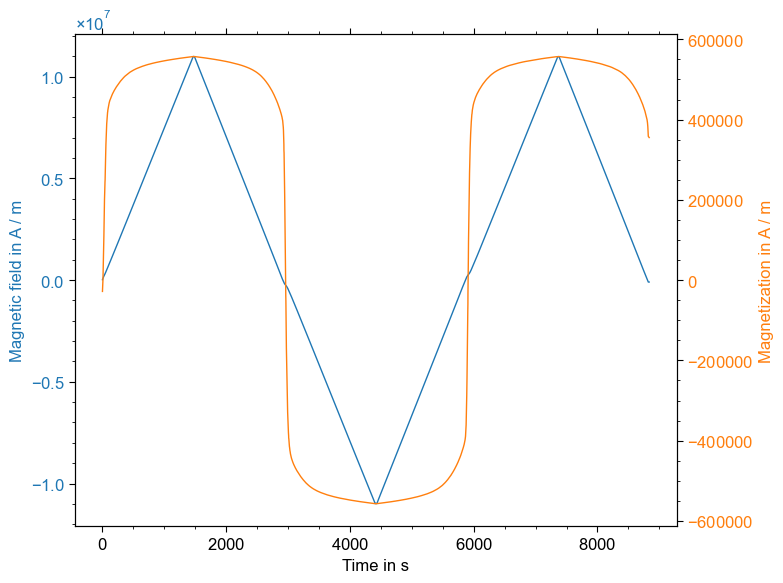

In [6]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
color1, color2 = "tab:blue", "tab:orange"

ax1.plot(mh.t.q, mh.H.q, color=color1)
ax1.set_xlabel(f"Time in {mh.t.unit}")
ax1.set_ylabel(f"Magnetic field in {mh.M.unit}", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2.plot(mh.t.q, mh.M.q, color=color2)
ax2.set_ylabel(f"Magnetization in {mh.M.unit}", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

## File Export

Since all magmeas classes inherit from the `mammos_entity.EntityCollection` class, they can also access its advanced export functionality.

In [7]:
import h5py

mh.to_csv("VSM_export.csv")

with h5py.File("Some_file.hdf5", "w") as f:
    grp = f.create_group("Some group label")
    mh.to_hdf5(grp)

mh.to_yaml("VSM_export.yml")